# Podejście I — klasyczna analiza odstępów RR

**Projekt:** Rozpoznawanie wybranych zaburzeń rytmu serca na podstawie sygnału EKG  
**Przedmiot:** Akwizycja danych biomedycznych  
**Baza danych:** MIT-BIH Arrhythmia Database

## Cel tego notebooka

Ten notebook realizuje **pierwsze, klasyczne podejście** do wykrywania arytmii, opisane w `arrhythmia_detection.ipynb`.

Idea jest prosta: wiele zaburzeń rytmu serca objawia się **zmianą regularności** pracy serca. Zamiast analizować skomplikowany kształt sygnału EKG, patrzymy wyłącznie na **odstępy RR** — czasy pomiędzy kolejnymi pikami R (kolejnymi uderzeniami serca).

### Sformułowanie zadania (wariant A)

Realizujemy **klasyfikację binarną na poziomie pojedynczego uderzenia**:

> dla każdego uderzenia serca decydujemy, czy jest ono **prawidłowe (normal)**, czy **nieprawidłowe (abnormal)** — wyłącznie na podstawie cech wyliczonych z odstępów RR.

Decyzję podejmujemy za pomocą **prostych, interpretowalnych reguł progowych**, a nie modelu uczenia maszynowego. Dzięki temu otrzymujemy **baseline** — punkt odniesienia, z którym później porównamy bardziej zaawansowane metody.

### Co jest mocną, a co słabą stroną tego podejścia

Analiza RR patrzy tylko na **rytm**, a nie na **morfologię** (kształt) zespołu QRS. Z tego wynika wprost:

- **dobrze** wykryje uderzenia **przedwczesne** (np. komorowe `V`, nadkomorowe `A`), bo zaburzają one regularność: krótki odstęp przed uderzeniem, a często długa **pauza kompensacyjna** po nim,
- **dobrze** wykryje **wypadnięcia / pauzy** w rytmie,
- **słabo lub wcale** wykryje zaburzenia widoczne głównie w kształcie uderzenia, ale o **normalnym rytmie** (np. bloki odnóg pęczka Hisa `L`, `R` — które zresztą w klasyfikacji AAMI i tak należą do klasy normalnej).

Te ograniczenia są **celowe** i stanowią motywację do kolejnych podejść w projekcie.

## Wejście i wyjście tego notebooka

**Dane wejściowe** — pliki CSV wygenerowane wcześniej w notebooku `mit_bih_arrhythmia_database.ipynb` (katalog `outputs_mitdb_analysis`):

- `annotations_all.csv` — wszystkie adnotacje ze wszystkich 48 rekordów (kolumny: `record_id`, `sample`, `time_sec`, `symbol`, `aux_note`),
- `records_summary.csv` — metadane rekordów (m.in. `record_id`, `fs`).


**Wynik** — ocena skuteczności baseline'u RR (macierz pomyłek, precision, recall, specificity, F1) wraz z analizą błędów i wnioskami.

## 1. Import bibliotek i konfiguracja

Potrzebujemy jedynie standardowego zestawu do analizy danych:

- `pandas` — wczytanie i przetwarzanie tabel CSV,
- `numpy` — operacje numeryczne (mediana, okna),
- `matplotlib` — wizualizacje rozkładów cech i wyników.

Nie importujemy `wfdb` — całość opiera się na wcześniej przygotowanych plikach CSV.

In [49]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

# Katalog z plikami CSV wygenerowanymi w mit_bih_arrhythmia_database.ipynb
DATA_DIR = Path("outputs_mitdb_analysis")

ANNOTATIONS_CSV = DATA_DIR / "annotations_all.csv"
RECORDS_CSV = DATA_DIR / "records_summary.csv"

print("Plik adnotacji:", ANNOTATIONS_CSV)
print("Plik metadanych:", RECORDS_CSV)

Plik adnotacji: outputs_mitdb_analysis/annotations_all.csv
Plik metadanych: outputs_mitdb_analysis/records_summary.csv


### Stałe projektu

Definiujemy w jednym miejscu najważniejsze parametry, do których będziemy się odwoływać w dalszej części:

- **rekordy z rozrusznikiem** (`paced beats`) — `102`, `104`, `107`, `217`. Te rekordy zawierają uderzenia stymulowane elektronicznie, o sztucznie narzuconym, regularnym rytmie. Ponieważ analizujemy **naturalną** regularność rytmu serca, **wykluczamy je** z analizy,
- **rozmiar okna lokalnego** `LOCAL_WINDOW = 5` — liczba uderzeń z każdej strony branych do oszacowania „typowego" rytmu w okolicy,
- **progi reguły** — startowe wartości progów dla wykrywania uderzeń przedwczesnych i pauz (dobierzemy je później na zbiorze treningowym).

In [50]:
# Rekordy z uderzeniami stymulowanymi rozrusznikiem (paced beats) -> wykluczamy
PACED_RECORDS = ["102", "104", "107", "217"]

# Rozmiar okna lokalnego (liczba uderzeń z KAŻDEJ strony bieżącego uderzenia)
LOCAL_WINDOW = 5

# Startowe progi reguły decyzyjnej (zostaną dostrojone na zbiorze treningowym)
THR_PREMATURE = 0.85   # rr_ratio < THR_PREMATURE  -> uderzenie przedwczesne
THR_PAUSE = 1.15       # rr_ratio > THR_PAUSE      -> pauza / wypadnięcie

print("Rekordy wykluczane (paced):", PACED_RECORDS)
print("Okno lokalne (+/- uderzeń):", LOCAL_WINDOW)
print("Progi startowe: premature <", THR_PREMATURE, " pause >", THR_PAUSE)

Rekordy wykluczane (paced): ['102', '104', '107', '217']
Okno lokalne (+/- uderzeń): 5
Progi startowe: premature < 0.85  pause > 1.15


## 2. Wczytanie danych

In [51]:
annotations_df = pd.read_csv(ANNOTATIONS_CSV, dtype={"record_id": str})
records_df = pd.read_csv(RECORDS_CSV, dtype={"record_id": str})

print("annotations_all.csv:", annotations_df.shape)
print("records_summary.csv:", records_df.shape)

annotations_all.csv: (112647, 5)
records_summary.csv: (48, 10)


### Podgląd tabeli adnotacji

Tabela `annotations_all.csv` zawiera **wszystkie** adnotacje ze wszystkich rekordów. Najważniejsze kolumny:

- `record_id` — z którego rekordu pochodzi adnotacja,
- `sample` — pozycja adnotacji w sygnale wyrażona jako **numer próbki**,
- `time_sec` — ta sama pozycja w sekundach,
- `symbol` — symbol adnotacji (typ uderzenia lub adnotacja techniczna),
- `aux_note` — dodatkowa informacja tekstowa (np. zmiana rytmu).

Uwaga: nie wszystkie wiersze to uderzenia serca. Część to **adnotacje techniczne**, np. `+` (zmiana rytmu) czy `~` (zmiana jakości sygnału / szum). Zajmiemy się tym w następnej sekcji.

In [52]:
annotations_df.head(10)

,record_id,sample,time_sec,symbol,aux_note
0,100,18,0.050000,+,(N
1,100,77,0.213889,N,NaN
2,100,370,1.027778,N,NaN
3,100,662,1.838889,N,NaN
4,100,946,2.627778,N,NaN
5,100,1231,3.419444,N,NaN
6,100,1515,4.208333,N,NaN
7,100,1809,5.025000,N,NaN
8,100,2044,5.677778,A,NaN
9,100,2402,6.672222,N,NaN


### Podgląd metadanych rekordów

Z pliku `records_summary.csv` w tym podejściu potrzebujemy przede wszystkim kolumny `fs` (częstotliwość próbkowania), aby przeliczać odstępy RR z próbek na sekundy. W bazie MIT-BIH `fs = 360 Hz` dla wszystkich rekordów, ale i tak odczytujemy tę wartość z danych — dzięki temu kod jest poprawny niezależnie od bazy.

In [53]:
records_df.head()

,record_id,fs,n_sig,sig_len,duration_min,sig_names,units,n_annotations,comments,has_paced_beats_record
0,100,360,2,650000,30.092593,"MLII, V5","mV, mV",2274,"69 M 1085 1629 x1 | Aldomet, Inderal",False
1,101,360,2,650000,30.092593,"MLII, V1","mV, mV",1874,75 F 1011 654 x1 | Diapres,False
2,102,360,2,650000,30.092593,"V5, V2","mV, mV",2192,84 F 1525 167 x1 | Digoxin | The rhythm is pac...,True
3,103,360,2,650000,30.092593,"MLII, V2","mV, mV",2091,"-1 M 742 654 x1 | Diapres, Xyloprim",False
4,104,360,2,650000,30.092593,"V5, V2","mV, mV",2311,"66 F 1567 694 x1 | Digoxin, Pronestyl | The ra...",True


## 3. Filtracja uderzeń — odtworzenie zbioru `beats_df`

Zanim policzymy odstępy RR, musimy zostawić **tylko adnotacje będące uderzeniami serca**. Robimy to w trzech krokach, spójnie z notebookiem `mit_bih_arrhythmia_database.ipynb`:

1. **mapowanie symboli na klasy AAMI** — standard AAMI grupuje wiele szczegółowych typów uderzeń w 5 klas: `N`, `S`, `V`, `F`, `Q`,
2. **mapowanie na klasę binarną** — `normal` (klasa `N`) vs `abnormal` (klasy `S`, `V`, `F`, `Q`); adnotacje techniczne dostają etykietę `ignore`,
3. **odrzucenie** adnotacji `ignore` oraz **wykluczenie** rekordów z rozrusznikiem.

### 3.1. Mapowanie symboli na klasy AAMI

Poniższe grupowanie jest standardem stosowanym w analizie MIT-BIH (tzw. klasy AAMI):

| Klasa AAMI | Znaczenie | Symbole źródłowe |
|---|---|---|
| `N` | uderzenia prawidłowe i okołoprawidłowe | `N`, `L`, `R`, `e`, `j` |
| `S` | nadkomorowe (supraventricular) | `A`, `a`, `J`, `S` |
| `V` | komorowe (ventricular) | `V`, `E` |
| `F` | zlewne (fusion) | `F` |
| `Q` | stymulowane / niesklasyfikowane | `/`, `f`, `Q` |

Symbole spoza tej tabeli (np. `+`, `~`) nie są uderzeniami — oznaczamy je jako `ignore`.

In [54]:
AAMI_GROUPS = {
    "N": ["N", "L", "R", "e", "j"],
    "S": ["A", "a", "J", "S"],
    "V": ["V", "E"],
    "F": ["F"],
    "Q": ["/", "f", "Q"],
}

SYMBOL_TO_AAMI = {
    symbol: group
    for group, symbols in AAMI_GROUPS.items()
    for symbol in symbols
}

def map_to_aami(symbol):
    return SYMBOL_TO_AAMI.get(symbol, "ignore")

def map_to_binary(symbol):
    # Klasa binarna: normal (N) vs abnormal (S, V, F, Q); ignore dla reszty
    aami = map_to_aami(symbol)
    if aami == "N":
        return "normal"
    elif aami in ["S", "V", "F", "Q"]:
        return "abnormal"
    else:
        return "ignore"

annotations_df["aami_class"] = annotations_df["symbol"].apply(map_to_aami)
annotations_df["binary_class"] = annotations_df["symbol"].apply(map_to_binary)

annotations_df[["record_id", "sample", "symbol", "aami_class", "binary_class"]].head(10)

,record_id,sample,symbol,aami_class,binary_class
0,100,18,+,ignore,ignore
1,100,77,N,N,normal
2,100,370,N,N,normal
3,100,662,N,N,normal
4,100,946,N,N,normal
5,100,1231,N,N,normal
6,100,1515,N,N,normal
7,100,1809,N,N,normal
8,100,2044,A,S,abnormal
9,100,2402,N,N,normal


### 3.2. Odrzucenie adnotacji technicznych

Zostawiamy tylko wiersze, które są faktycznymi uderzeniami (klasa AAMI różna od `ignore`). Sprawdzamy, ile adnotacji odpada — to głównie adnotacje rytmu (`+`) i jakości sygnału (`~`).

In [55]:
n_all = len(annotations_df)
beats_df = annotations_df[annotations_df["aami_class"] != "ignore"].copy()
n_beats = len(beats_df)

print("Wszystkie adnotacje:        ", n_all)
print("Adnotacje uderzeń:          ", n_beats)
print("Odrzucone (techniczne):     ", n_all - n_beats)

Wszystkie adnotacje:         112647
Adnotacje uderzeń:           109494
Odrzucone (techniczne):      3153


### 3.3. Wykluczenie rekordów z rozrusznikiem

Rekordy `102`, `104`, `107`, `217` zawierają uderzenia stymulowane rozrusznikiem. Ich rytm jest narzucony elektronicznie i sztucznie regularny, więc nie odzwierciedla naturalnej pracy serca. Ponieważ analiza RR ma wykrywać **naturalne** zaburzenia rytmu, **wykluczamy te rekordy w całości**. Jest to świadoma decyzja projektowa zgodna z typową praktyką przy klasyfikacji AAMI.

In [56]:
before = len(beats_df)
beats_df = beats_df[~beats_df["record_id"].isin(PACED_RECORDS)].copy()
after = len(beats_df)

print("Uderzeń przed wykluczeniem paced:", before)
print("Uderzeń po wykluczeniu paced:    ", after)
print("Usunięto uderzeń (paced):        ", before - after)
print("Pozostałe rekordy:               ", beats_df["record_id"].nunique())

Uderzeń przed wykluczeniem paced: 109494
Uderzeń po wykluczeniu paced:     100733
Usunięto uderzeń (paced):         8761
Pozostałe rekordy:                44


### 3.4. Kontrola rozkładu klas

Po filtracji sprawdzamy rozkład klas. Spodziewamy się **silnego niezbalansowania** — uderzeń prawidłowych (`normal`) jest wielokrotnie więcej niż nieprawidłowych (`abnormal`). To kluczowa obserwacja: będzie miała bezpośredni wpływ na dobór metryk oceny.

In [57]:
aami_counts = beats_df["aami_class"].value_counts().reindex(["N", "S", "V", "F", "Q"]).fillna(0).astype(int)
binary_counts = beats_df["binary_class"].value_counts().reindex(["normal", "abnormal"]).fillna(0).astype(int)

print("Rozkład klas AAMI:")
print(aami_counts)
print("\nRozkład klas binarnych:")
print(binary_counts)
print("\nUdział klasy abnormal: {:.2f}%".format(100 * binary_counts["abnormal"] / binary_counts.sum()))

Rozkład klas AAMI:
aami_class
N    90125
S     2781
V     7009
F      803
Q       15
Name: count, dtype: int64

Rozkład klas binarnych:
binary_class
normal      90125
abnormal    10608
Name: count, dtype: int64

Udział klasy abnormal: 10.53%


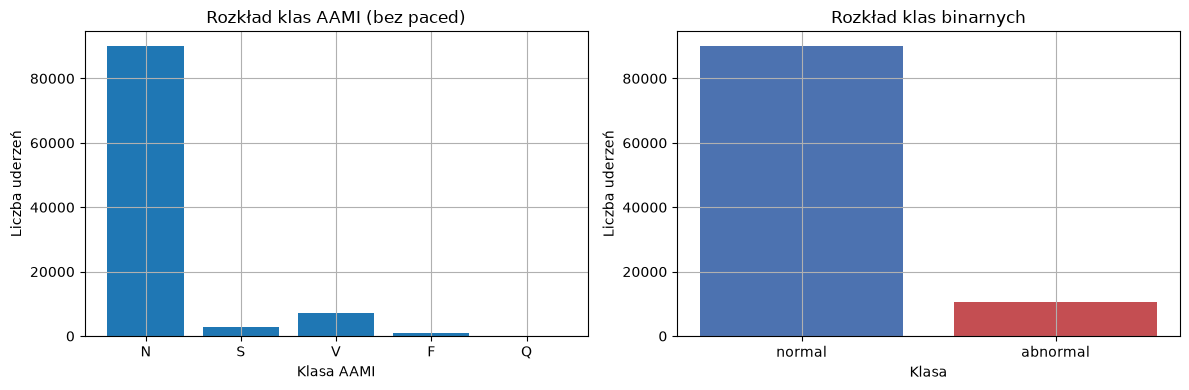

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(aami_counts.index, aami_counts.values)
axes[0].set_title("Rozkład klas AAMI (bez paced)")
axes[0].set_xlabel("Klasa AAMI")
axes[0].set_ylabel("Liczba uderzeń")

axes[1].bar(binary_counts.index, binary_counts.values, color=["#4C72B0", "#C44E52"])
axes[1].set_title("Rozkład klas binarnych")
axes[1].set_xlabel("Klasa")
axes[1].set_ylabel("Liczba uderzeń")

plt.tight_layout()
plt.show()

## 4. Obliczenie odstępów RR

**Odstęp RR** to czas pomiędzy dwoma kolejnymi uderzeniami serca (kolejnymi pikami R). Wyliczamy go jako różnicę pozycji (`sample`) dwóch sąsiednich uderzeń, podzieloną przez częstotliwość próbkowania `fs`:

$$ RR = \frac{\Delta \text{sample}}{fs} \quad [\text{s}] $$

Dla każdego uderzenia liczymy dwa odstępy:

- `rr_prev_sec` — odstęp do **poprzedniego** uderzenia,
- `rr_next_sec` — odstęp do **następnego** uderzenia.

### Ważne zasady

- RR liczymy **osobno dla każdego rekordu** (grupowanie po `record_id`) i po **posortowaniu** uderzeń według pozycji `sample`. Odstęp nigdy nie może „przeskakiwać" granicy między rekordami — to różne zapisy, często różni pacjenci.
- RR liczymy **już po** odfiltrowaniu adnotacji technicznych i wykluczeniu rekordów paced. Dzięki temu `rr_prev` łączy zawsze dwa kolejne **uderzenia**, a nie uderzenie z adnotacją techniczną.
- **Pierwsze** uderzenie w rekordzie nie ma poprzednika, a **ostatnie** nie ma następnika — te wartości będą `NaN`. Zajmiemy się tym świadomie w regule decyzyjnej.

In [59]:
def add_rr_intervals(df, records_df):
    # Dodaje kolumny rr_prev_sec i rr_next_sec, licząc RR osobno dla każdego rekordu.
    parts = []
    fs_by_record = records_df.set_index("record_id")["fs"].to_dict()

    for rid, group in df.sort_values(["record_id", "sample"]).groupby("record_id"):
        g = group.copy()
        fs = fs_by_record[rid]
        g["rr_prev_sec"] = g["sample"].diff() / fs          # do poprzedniego uderzenia
        g["rr_next_sec"] = g["sample"].diff(-1).abs() / fs  # do następnego uderzenia
        parts.append(g)

    return pd.concat(parts, ignore_index=True)

beats_df = add_rr_intervals(beats_df, records_df)

beats_df[["record_id", "sample", "symbol", "aami_class", "binary_class",
          "rr_prev_sec", "rr_next_sec"]].head(10)

,record_id,sample,symbol,aami_class,binary_class,rr_prev_sec,rr_next_sec
0,100,77,N,N,normal,NaN,0.813889
1,100,370,N,N,normal,0.813889,0.811111
2,100,662,N,N,normal,0.811111,0.788889
3,100,946,N,N,normal,0.788889,0.791667
4,100,1231,N,N,normal,0.791667,0.788889
5,100,1515,N,N,normal,0.788889,0.816667
6,100,1809,N,N,normal,0.816667,0.652778
7,100,2044,A,S,abnormal,0.652778,0.994444
8,100,2402,N,N,normal,0.994444,0.844444
9,100,2706,N,N,normal,0.844444,0.811111


## 5. Cechy RR — kontekst lokalny rytmu

Sama wartość odstępu RR nie wystarcza. Uderzenie o odstępie 0,6 s może być:

- **przedwczesne**, jeśli sąsiednie uderzenia mają odstępy ~0,9 s,
- **zupełnie normalne**, jeśli cały lokalny rytm jest szybki (~0,6 s).

Dlatego najważniejsze są cechy **względne** — porównujące bieżący odstęp RR z **typowym rytmem w okolicy**. Ten lokalny kontekst szacujemy jako **medianę** odstępów RR z okna `±5` uderzeń wokół bieżącego.

### Dlaczego mediana, a nie średnia?

Mediana jest **odporna na wartości odstające**. Jeśli w oknie znajdzie się jedno przedwczesne uderzenie (krótki RR) lub pauza (długi RR), mediana niemal się nie zmieni, a średnia zostałaby zaburzona. Chcemy, by punkt odniesienia opisywał „normalny" rytm okolicy, a nie był psuty przez pojedyncze anomalie.

### Dlaczego okno centrowane i z wykluczeniem bieżącego uderzenia?

- **Centrowane** (`±5`) — korzysta z uderzeń przed i po bieżącym, więc lepiej szacuje lokalny rytm niż okno patrzące tylko wstecz. Pracujemy offline na całym zapisie, więc możemy patrzeć w obie strony.
- **Z wykluczeniem bieżącego uderzenia** — punkt odniesienia ma opisywać **otoczenie**, a nie samo badane uderzenie. Gdyby przedwczesne uderzenie wliczało własny (krótki) RR do mediany, zaniżyłoby swój punkt odniesienia i samo „ukryłoby" swoją przedwczesność.

### Definicje cech

Dla każdego uderzenia liczymy:

| Cecha | Definicja | Interpretacja |
|---|---|---|
| `rr_prev_sec`, `rr_next_sec` | odstępy do sąsiadów | podstawa |
| `hr_prev` | `60 / rr_prev_sec` | chwilowe tętno [uderzenia/min] |
| `rr_local_median` | mediana RR z okna `±5` (bez bieżącego) | „typowy" lokalny rytm |
| `rr_local_mean` | średnia RR z okna `±5` (bez bieżącego) | pomocniczo |
| `rr_ratio` | `rr_prev_sec / rr_local_median` | **kluczowa cecha**: `<1` przedwczesne, `>1` pauza |
| `rr_prev_next_ratio` | `rr_prev_sec / rr_next_sec` | wykrywa wzorzec przedwczesne→pauza kompensacyjna |
| `rr_deviation` | `rr_prev_sec − rr_local_median` | bezwzględne odchylenie od lokalnego rytmu [s] |

In [60]:
def add_local_rr_features(df, window=LOCAL_WINDOW):
    parts = []

    for rid, group in df.sort_values(["record_id", "sample"]).groupby("record_id"):
        g = group.reset_index(drop=True).copy()
        rr = g["rr_prev_sec"].values
        n = len(g)

        local_median = np.full(n, np.nan)
        local_mean = np.full(n, np.nan)

        for i in range(n):
            lo = max(0, i - window)
            hi = min(n, i + window + 1)
            # indeksy sąsiadów z wykluczeniem bieżącego uderzenia
            neighbours = [k for k in range(lo, hi) if k != i]
            vals = rr[neighbours]
            vals = vals[~np.isnan(vals)]
            if len(vals) > 0:
                local_median[i] = np.median(vals)
                local_mean[i] = np.mean(vals)

        g["rr_local_median"] = local_median
        g["rr_local_mean"] = local_mean
        parts.append(g)

    out = pd.concat(parts, ignore_index=True)

    # cechy pochodne
    out["hr_prev"] = 60.0 / out["rr_prev_sec"]
    out["rr_ratio"] = out["rr_prev_sec"] / out["rr_local_median"]
    out["rr_prev_next_ratio"] = out["rr_prev_sec"] / out["rr_next_sec"]
    out["rr_deviation"] = out["rr_prev_sec"] - out["rr_local_median"]
    return out

beats_df = add_local_rr_features(beats_df)

beats_df[["record_id", "symbol", "aami_class", "binary_class",
          "rr_prev_sec", "rr_local_median", "rr_ratio",
          "rr_prev_next_ratio", "rr_deviation"]].head(10)

,record_id,symbol,aami_class,binary_class,rr_prev_sec,rr_local_median,rr_ratio,rr_prev_next_ratio,rr_deviation
0,100,N,N,normal,NaN,0.791667,NaN,NaN,NaN
1,100,N,N,normal,0.813889,0.791667,1.028070,1.003425,0.022222
2,100,N,N,normal,0.811111,0.790278,1.026362,1.028169,0.020833
3,100,N,N,normal,0.788889,0.811111,0.972603,0.996491,-0.022222
4,100,N,N,normal,0.791667,0.812500,0.974359,1.003521,-0.020833
5,100,N,N,normal,0.788889,0.811111,0.972603,0.965986,-0.022222
6,100,N,N,normal,0.816667,0.801389,1.019064,1.251064,0.015278
7,100,A,S,abnormal,0.652778,0.801389,0.814558,0.656425,-0.148611
8,100,N,N,normal,0.994444,0.790278,1.258348,1.177632,0.204167
9,100,N,N,normal,0.844444,0.801389,1.053726,1.041096,0.043056


## 6. Analiza eksploracyjna cech względem klas

Zanim zbudujemy regułę, sprawdźmy, czy cechy RR faktycznie **różnicują** uderzenia prawidłowe i nieprawidłowe. Jeśli podejście ma sens, powinniśmy zobaczyć, że:

- uderzenia **abnormal** (głównie przedwczesne) mają `rr_ratio` przesunięty w stronę wartości **mniejszych od 1** (krótki RR względem otoczenia),
- część uderzeń abnormal ma `rr_ratio` **większy od 1** (pauzy),
- uderzenia **normal** skupiają się wokół `rr_ratio ≈ 1`.

Do wykresów ograniczamy oś `rr_ratio` do sensownego zakresu (wartości skrajne to zwykle artefakty), ale **pamiętajmy: obcięcie dotyczy tylko wizualizacji** — w cechach i regule używamy pełnych, nieobciętych wartości.

### 6.1. Rozkład `rr_ratio` w podziale na klasę binarną

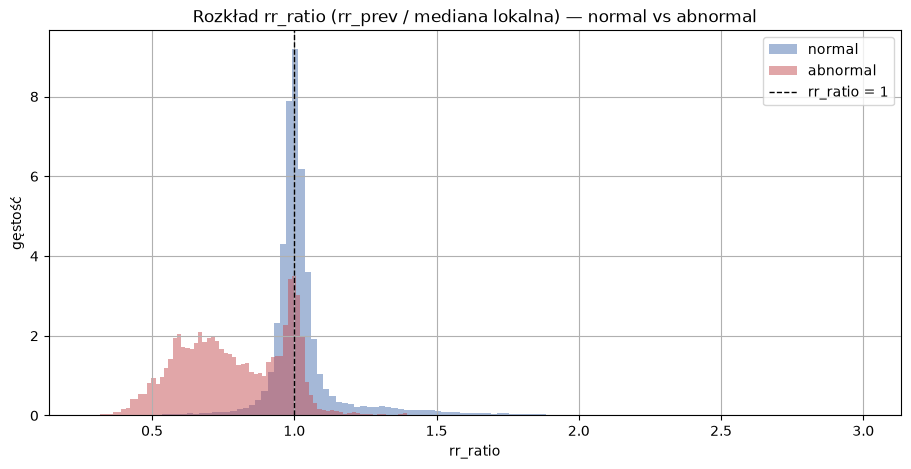

In [61]:
mask = beats_df["rr_ratio"].notna() & (beats_df["rr_ratio"] > 0) & (beats_df["rr_ratio"] < 3)

plt.figure(figsize=(11, 5))
for cls, color in [("normal", "#4C72B0"), ("abnormal", "#C44E52")]:
    vals = beats_df.loc[mask & (beats_df["binary_class"] == cls), "rr_ratio"]
    plt.hist(vals, bins=120, alpha=0.5, density=True, label=cls, color=color)

plt.axvline(1.0, color="black", linestyle="--", linewidth=1, label="rr_ratio = 1")
plt.title("Rozkład rr_ratio (rr_prev / mediana lokalna) — normal vs abnormal")
plt.xlabel("rr_ratio")
plt.ylabel("gęstość")
plt.legend()
plt.show()

### 6.2. Rozkład `rr_ratio` w podziale na klasy AAMI

Tu spodziewamy się, że klasy **S** (nadkomorowe) i **V** (komorowe) — typowo przedwczesne — będą miały `rr_ratio` przesunięty poniżej 1, podczas gdy **N** skupia się wokół 1.

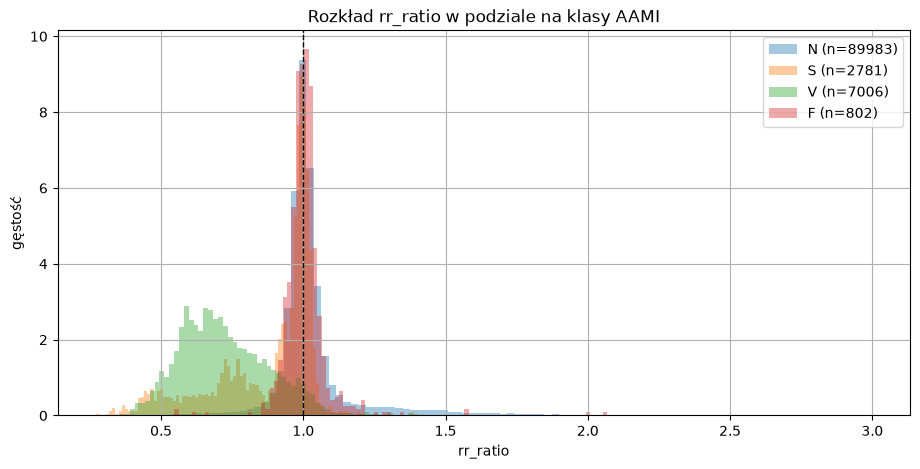

In [62]:
plt.figure(figsize=(11, 5))
for cls in ["N", "S", "V", "F"]:
    vals = beats_df.loc[mask & (beats_df["aami_class"] == cls), "rr_ratio"]
    if len(vals) > 0:
        plt.hist(vals, bins=100, alpha=0.4, density=True, label=f"{cls} (n={len(vals)})")

plt.axvline(1.0, color="black", linestyle="--", linewidth=1)
plt.title("Rozkład rr_ratio w podziale na klasy AAMI")
plt.xlabel("rr_ratio")
plt.ylabel("gęstość")
plt.legend()
plt.show()

### 6.3. Wzorzec „przedwczesne → pauza kompensacyjna"

Uderzenie przedwczesne często wygląda tak: **krótki** odstęp do poprzednika (`rr_prev` mały) i **długi** odstęp do następnika (`rr_next` duży, bo serce „nadrabia" pauzą). Na wykresie rozrzutu `rr_prev` vs `rr_next` takie uderzenia powinny układać się **poniżej** przekątnej (krótki prev, długi next), oddzielnie od chmury uderzeń normalnych skupionej wokół przekątnej.

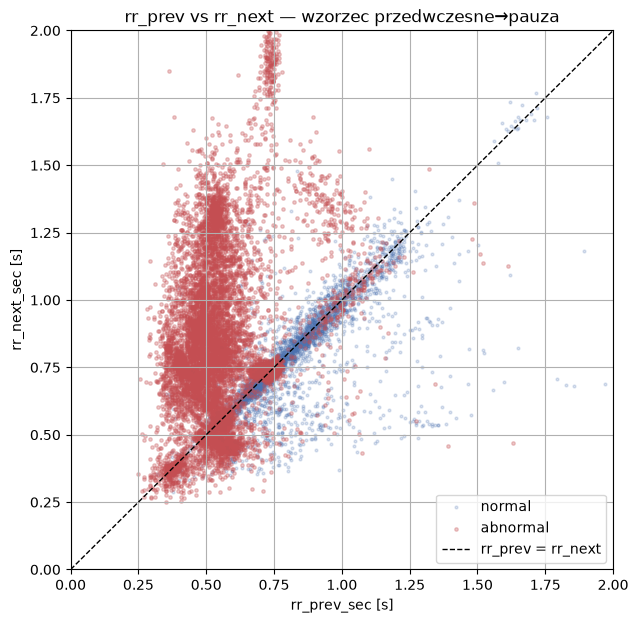

In [63]:
sample_n = beats_df[beats_df["binary_class"] == "normal"].sample(
    min(4000, (beats_df["binary_class"] == "normal").sum()), random_state=0)
sample_a = beats_df[beats_df["binary_class"] == "abnormal"]

plt.figure(figsize=(7, 7))
plt.scatter(sample_n["rr_prev_sec"], sample_n["rr_next_sec"],
            s=4, alpha=0.2, color="#4C72B0", label="normal")
plt.scatter(sample_a["rr_prev_sec"], sample_a["rr_next_sec"],
            s=6, alpha=0.3, color="#C44E52", label="abnormal")
plt.plot([0, 2], [0, 2], "k--", linewidth=1, label="rr_prev = rr_next")
plt.xlim(0, 2); plt.ylim(0, 2)
plt.title("rr_prev vs rr_next — wzorzec przedwczesne→pauza")
plt.xlabel("rr_prev_sec [s]")
plt.ylabel("rr_next_sec [s]")
plt.legend()
plt.show()

## 7. Reguła klasyfikacyjna

Sercem klasycznego podejścia jest **prosta, interpretowalna reguła**. Klasyfikujemy uderzenie jako **abnormal**, jeśli jego rytm lokalnie odbiega od otoczenia — w jednym z dwóch wzorców:

1. **uderzenie przedwczesne** — `rr_ratio < THR_PREMATURE` (odstęp do poprzednika wyraźnie **krótszy** niż lokalna mediana),
2. **pauza / wypadnięcie** — `rr_ratio > THR_PAUSE` (odstęp do poprzednika wyraźnie **dłuższy** niż lokalna mediana).

W przeciwnym razie uderzenie uznajemy za **normal**.

### Obsługa wartości brzegowych (NaN)

Uderzenia na granicy rekordu nie mają pełnego kontekstu (`rr_ratio = NaN`). Zgodnie z wcześniejszą decyzją traktujemy brak danych jako **brak przesłanki do flagi** — takie uderzenie domyślnie klasyfikujemy jako **normal**. To zachowawcze i bezpieczne: nie zgłaszamy anomalii bez danych ją uzasadniających.

Funkcja zwraca również **przyczynę** decyzji (`premature` / `pause` / `normal`), co przyda się w analizie błędów i przy prezentacji.

In [64]:
def classify_beats_by_rr(df, thr_premature=THR_PREMATURE, thr_pause=THR_PAUSE):
    # Reguła dwukierunkowa na rr_ratio. Zwraca (pred_binary, reason).
    ratio = df["rr_ratio"]

    is_premature = ratio < thr_premature
    is_pause = ratio > thr_pause

    reason = np.where(is_premature, "premature",
             np.where(is_pause, "pause", "normal"))
    reason = pd.Series(reason, index=df.index)

    # NaN (brzegi rekordu) -> brak przesłanki -> normal
    reason[ratio.isna()] = "normal"

    pred = np.where(reason == "normal", "normal", "abnormal")
    pred = pd.Series(pred, index=df.index)
    return pred, reason

Funkcję pomocniczą do liczenia metryk definiujemy raz i będziemy jej używać zarówno przy strojeniu progów, jak i przy ocenie końcowej.

In [65]:
def compute_metrics(y_true, y_pred, positive="abnormal"):
    # Zwraca słownik metryk dla klasyfikacji binarnej (klasa pozytywna = abnormal).
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    TP = int(np.sum((y_true == positive) & (y_pred == positive))) # reguła powiedziała abnormal i ma rację. Wykryta arytmia.
    FP = int(np.sum((y_true != positive) & (y_pred == positive))) # reguła powiedziała abnormal, a uderzenie naprawdę jest normal. Fałszywy alarm - brak arytmii, niepoprawne wykrycie arytmii przez algorytm
    TN = int(np.sum((y_true != positive) & (y_pred != positive))) # reguła powiedziała normal, uderzenie naprawdę jest normal. Dobra, cicha decyzja — nie ma arytmii i reguła o tym wie.
    FN = int(np.sum((y_true == positive) & (y_pred != positive))) # reguła powiedziała normal, a uderzenie naprawdę jest arytmią. Przeoczenie przez algorytm

    precision = TP / (TP + FP) if (TP + FP) else 0.0 # z tego co oznaczyliśmy jako arytmię, ile naprawdę nią było,
    recall = TP / (TP + FN) if (TP + FN) else 0.0  # z wszystkich prawdziwych arytmii, ile wykryliśmy,
    specificity = TN / (TN + FP) if (TN + FP) else 0.0 # z prawidłowych uderzeń, ile poprawnie pominęliśmy (poprawnie nie wykryta arytmia)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0 # średnia harmoniczna łączy precision i recall w jedną liczbę, która jest wysoka tylko wtedy, gdy obie są wysokie.
    accuracy = (TP + TN) / (TP + TN + FP + FN) # ze wszystkich uderzeń zlicamy te, które sklasyfikowano poprawnie (i TP, i TN)

    return {
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
        "accuracy": accuracy, "precision": precision,
        "recall": recall, "specificity": specificity, "f1": f1,
    }

## 8. Dobór progów na zbiorze treningowym (DS1)

Progi `THR_PREMATURE` i `THR_PAUSE` dobieramy **wyłącznie na zbiorze treningowym DS1**, a ostateczną ocenę przeprowadzimy na **rozłącznym** zbiorze testowym DS2. To kluczowa zasada uczciwej ewaluacji: gdybyśmy dobierali progi patrząc na zbiór testowy, „podejrzelibyśmy" odpowiedzi i zawyżyli wyniki.

### Podział inter-patient (DS1 / DS2)

Używamy standardowego podziału MIT-BIH na poziomie **rekordów (pacjentów)**, zdefiniowanego w `mit_bih_arrhythmia_database.ipynb`. Dzięki temu uderzenia tego samego pacjenta nie trafiają jednocześnie do treningu i testu (unikamy przecieku informacji).

In [66]:
DS1_TRAIN = [
    "101", "106", "108", "109", "112", "114", "115", "116", "118", "119", "122", "124",
    "201", "203", "205", "207", "208", "209", "215", "220", "223", "230"
]

DS2_TEST = [
    "100", "103", "105", "111", "113", "117", "121", "123", "200", "202", "210", "212",
    "213", "214", "219", "221", "222", "228", "231", "232", "233", "234"
]

def split_name(record_id):
    if record_id in DS1_TRAIN:
        return "DS1_train"
    if record_id in DS2_TEST:
        return "DS2_test"
    return "excluded"

beats_df["split"] = beats_df["record_id"].apply(split_name)

train_df = beats_df[beats_df["split"] == "DS1_train"].copy()
test_df = beats_df[beats_df["split"] == "DS2_test"].copy()

print("Uderzenia w DS1 (train):", len(train_df))
print("Uderzenia w DS2 (test): ", len(test_df))
print("\nRozkład klas w DS1:")
print(train_df["binary_class"].value_counts())
print("\nRozkład klas w DS2:")
print(test_df["binary_class"].value_counts())

Uderzenia w DS1 (train): 51021
Uderzenia w DS2 (test):  49712

Rozkład klas w DS1:
binary_class
normal      45866
abnormal     5155
Name: count, dtype: int64

Rozkład klas w DS2:
binary_class
normal      44259
abnormal     5453
Name: count, dtype: int64


### 8.1. Przeszukiwanie progu dla uderzeń przedwczesnych

Najpierw stroimy `THR_PREMATURE` (próg na przedwczesność). Dla zakresu wartości liczymy metryki na DS1 i patrzymy, jak zmienia się **F1** oraz **recall** klasy abnormal. Próg pauzy ustawiamy na razie na wartość startową.

In [67]:
premature_grid = np.round(np.arange(0.70, 0.96, 0.01), 2)

rows = []
for thr in premature_grid:
    pred, _ = classify_beats_by_rr(train_df, thr_premature=thr, thr_pause=THR_PAUSE)
    m = compute_metrics(train_df["binary_class"], pred)
    rows.append({"thr_premature": thr, "precision": m["precision"],
                 "recall": m["recall"], "f1": m["f1"]})

premature_sweep = pd.DataFrame(rows)
premature_sweep

,thr_premature,precision,recall,f1
0,0.70,0.307623,0.395344,0.346010
1,0.71,0.314281,0.410669,0.356068
2,0.72,0.323084,0.430068,0.368977
3,0.73,0.330568,0.448303,0.380537
4,0.74,0.338902,0.468283,0.393224
5,0.75,0.345947,0.485936,0.404163
6,0.76,0.351774,0.502037,0.413683
7,0.77,0.360245,0.524539,0.427138
8,0.78,0.366890,0.542968,0.437891
9,0.79,0.372465,0.559457,0.447201


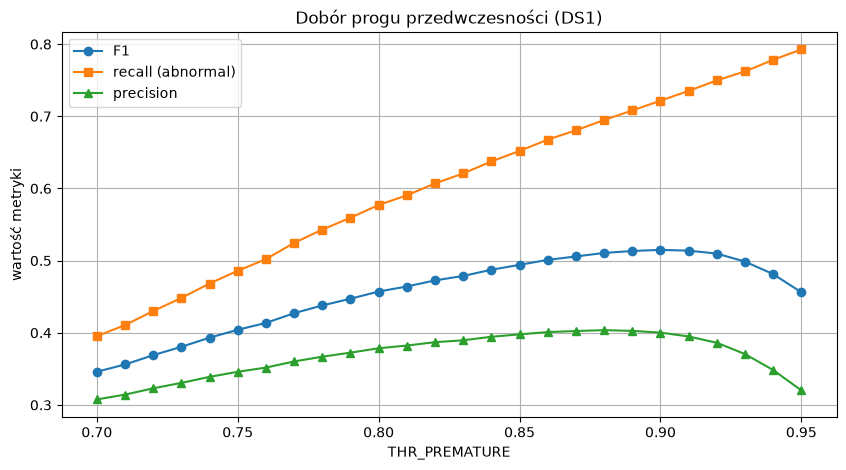

In [68]:
plt.figure(figsize=(10, 5))
plt.plot(premature_sweep["thr_premature"], premature_sweep["f1"], marker="o", label="F1")
plt.plot(premature_sweep["thr_premature"], premature_sweep["recall"], marker="s", label="recall (abnormal)")
plt.plot(premature_sweep["thr_premature"], premature_sweep["precision"], marker="^", label="precision")
plt.title("Dobór progu przedwczesności (DS1)")
plt.xlabel("THR_PREMATURE")
plt.ylabel("wartość metryki")
plt.legend()
plt.show()

### 8.2. Przeszukiwanie progu dla pauz

Następnie, przy ustalonym najlepszym progu przedwczesności, stroimy `THR_PAUSE`.

#### Ważna obserwacja — dlaczego siatka ma ograniczony zakres?

Podczas wstępnych testów okazało się, że F1 rośnie monotonicznie wraz
z wartością `THR_PAUSE` — im wyższy próg, tym lepszy wynik na DS1.
To zachowanie jest **zamierzone i zrozumiałe**, gdy spojrzymy na to,
jak MIT-BIH adnotuje uderzenia.

**Adnotacje opisują morfologię, nie kontekst rytmu.**
Ekspert oznacza każde uderzenie symbolem opisującym jego *wygląd*
w sygnale EKG, a nie jego pozycję w sekwencji uderzeń.
Uderzenie stojące zaraz po przedwczesnym pobudzeniu komorowym (`V`)
ma długi `rr_prev` (bo poprzednikiem było krótkie przedwczesne),
ale morfologicznie wygląda normalnie — ekspert oznacza je więc jako `N`.

**Co z tego wynika dla reguły RR?**
Kiedy `THR_PAUSE` jest niski (np. 1.15), reguła flaguje te „popauzy N"
jako `abnormal`. Adnotacja mówi jednak `normal` → powstaje **fałszywy
alarm (FP)**. Im niższy próg, tym więcej takich FP, tym gorsza precision,
tym gorszy F1.

Podnosząc `THR_PAUSE` w górę coraz rzadziej flagujemy te uderzenia,
więc F1 rośnie — ale nie dlatego, że reguła staje się lepsza w wykrywaniu
pauz, lecz dlatego, że przestaje generować konkretny typ błędu.

**Wniosek:** zamiast szukać „optymalnego" progu metodą sweep na nieograniczonej
siatce, ograniczamy zakres do **fizjologicznie sensownych wartości**.
Pauza kompensacyjna po typowej ekstrasystolii rzadko przekracza
`rr_ratio ≈ 1.5` — powyżej tej granicy mamy do czynienia z klinicznie
istotną bradykardią lub wyjątkowymi zdarzeniami (np. blok AV II/III stopnia).
Poszukiwanie progu powyżej 1.5 traciłoby sens kliniczny.

To odkrycie jest samo w sobie wartościowym wnioskiem z analizy:
**prosta reguła na `rr_ratio` słabo nadaje się do wykrywania pauz,
bo baza danych nie rozróżnia „normalnego uderzenia z długim RR"
od „uderzenia będącego pauzą patologiczną".**
Morfologia uderzenia — niedostępna w Podejściu I — byłaby tu kluczowa.

In [69]:
best_premature = float(premature_sweep.loc[premature_sweep["f1"].idxmax(), "thr_premature"])
print("Najlepszy THR_PREMATURE wg F1 na DS1:", best_premature)

pause_grid = np.round(np.arange(1.05, 1.55, 0.01), 2)

rows = []
for thr in pause_grid:
    pred, _ = classify_beats_by_rr(train_df, thr_premature=best_premature, thr_pause=thr)
    m = compute_metrics(train_df["binary_class"], pred)
    rows.append({"thr_pause": thr, "precision": m["precision"],
                 "recall": m["recall"], "f1": m["f1"]})

pause_sweep = pd.DataFrame(rows)
pause_sweep

Najlepszy THR_PREMATURE wg F1 na DS1: 0.9


,thr_pause,precision,recall,f1
0,1.05,0.277414,0.755771,0.405854
1,1.06,0.301000,0.747042,0.429105
2,1.07,0.322200,0.741028,0.449121
3,1.08,0.339444,0.736372,0.464684
4,1.09,0.353436,0.733269,0.476972
5,1.10,0.364181,0.730553,0.486061
6,1.11,0.373200,0.728807,0.493628
7,1.12,0.380938,0.726479,0.499800
8,1.13,0.387901,0.723957,0.505143
9,1.14,0.394723,0.722599,0.510554


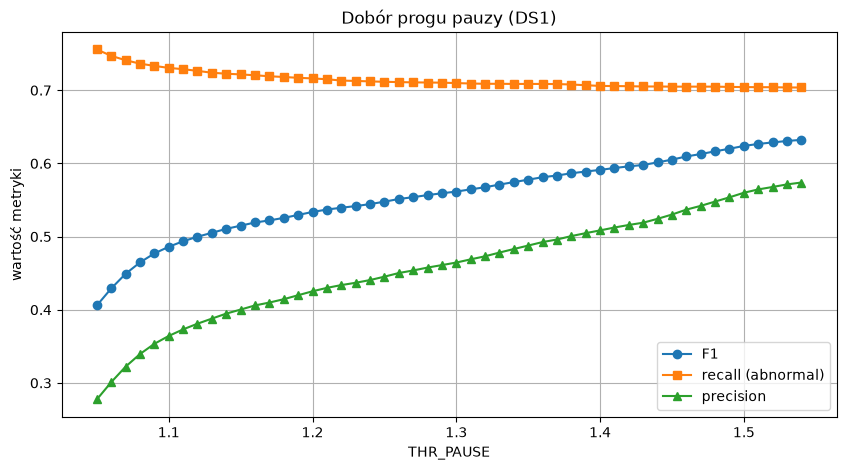

In [70]:
plt.figure(figsize=(10, 5))
plt.plot(pause_sweep["thr_pause"], pause_sweep["f1"], marker="o", label="F1")
plt.plot(pause_sweep["thr_pause"], pause_sweep["recall"], marker="s", label="recall (abnormal)")
plt.plot(pause_sweep["thr_pause"], pause_sweep["precision"], marker="^", label="precision")
plt.title("Dobór progu pauzy (DS1)")
plt.xlabel("THR_PAUSE")
plt.ylabel("wartość metryki")
plt.legend()
plt.show()

In [71]:
best_pause = float(pause_sweep.loc[pause_sweep["f1"].idxmax(), "thr_pause"])
print("Najlepszy THR_PAUSE wg F1 na DS1:", best_pause)
print("\n>>> Wybrane progi (dostrojone na DS1):")
print("    THR_PREMATURE =", best_premature)
print("    THR_PAUSE     =", best_pause)

Najlepszy THR_PAUSE wg F1 na DS1: 1.54

>>> Wybrane progi (dostrojone na DS1):
    THR_PREMATURE = 0.9
    THR_PAUSE     = 1.54


### 8.3. Wynik na DS1 dla wybranych progów

Dla kompletności sprawdzamy metryki na zbiorze treningowym przy ostatecznie wybranych progach. **Uwaga:** to nie jest miara jakości modelu — wynik na danych, na których strojono progi, jest zwykle optymistyczny. Prawdziwą ocenę da dopiero DS2.

In [82]:
pred_train, _ = classify_beats_by_rr(train_df, thr_premature=best_premature, thr_pause=best_pause)
metrics_train = compute_metrics(train_df["binary_class"], pred_train)
pd.Series(metrics_train)

TP              3628.000000
FP              2694.000000
TN             43172.000000
FN              1527.000000
accuracy           0.917269
precision          0.573869
recall             0.703783
specificity        0.941264
f1                 0.632221
dtype: float64

## 9. Ewaluacja na zbiorze testowym (DS2)

To **właściwa ocena** baseline'u: stosujemy progi dostrojone na DS1 do **nigdy wcześniej niewidzianego** zbioru DS2.

### Dlaczego accuracy może mylić?

Klasy są silnie niezbalansowane — uderzeń `normal` jest wielokrotnie więcej. Klasyfikator, który **wszystko** uznałby za normal, osiągnąłby wysoką accuracy, nie wykrywając **ani jednej** arytmii. Dlatego patrzymy przede wszystkim na:

- **recall (czułość) klasy abnormal** — jaki odsetek rzeczywistych arytmii udało się wykryć. To najważniejsza metryka w tym zadaniu,
- **precision** — jaki odsetek zgłoszonych arytmii był prawdziwy,
- **specificity** — jaki odsetek prawidłowych uderzeń poprawnie rozpoznano,
- **F1** — kompromis precision/recall.

In [73]:
pred_test, reason_test = classify_beats_by_rr(test_df, thr_premature=best_premature, thr_pause=best_pause)
test_df = test_df.copy()
test_df["pred"] = pred_test
test_df["reason"] = reason_test

metrics_test = compute_metrics(test_df["binary_class"], pred_test)
pd.Series(metrics_test).round(4)

TP              3299.0000
FP              4181.0000
TN             40078.0000
FN              2154.0000
accuracy           0.8726
precision          0.4410
recall             0.6050
specificity        0.9055
f1                 0.5102
dtype: float64

### 9.1. Macierz pomyłek

Macierz pomyłek pokazuje liczby TP, FP, TN, FN — czyli dokładnie, gdzie reguła trafia, a gdzie się myli.

In [74]:
def confusion_table(y_true, y_pred):
    return pd.crosstab(
        pd.Series(np.asarray(y_true), name="rzeczywista"),
        pd.Series(np.asarray(y_pred), name="przewidziana"),
        dropna=False,
    ).reindex(index=["normal", "abnormal"], columns=["normal", "abnormal"], fill_value=0)

cm = confusion_table(test_df["binary_class"], test_df["pred"])
cm

przewidziana,normal,abnormal
rzeczywista,,
normal,40078,4181
abnormal,2154,3299


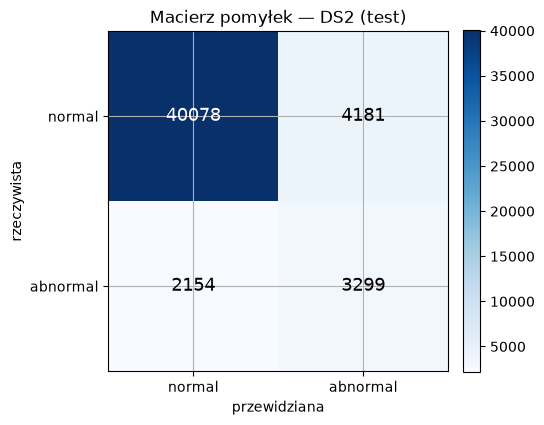

In [75]:
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["normal", "abnormal"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["normal", "abnormal"])
ax.set_xlabel("przewidziana"); ax.set_ylabel("rzeczywista")
ax.set_title("Macierz pomyłek — DS2 (test)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm.values[i, j]), ha="center", va="center",
                color="white" if cm.values[i, j] > cm.values.max() / 2 else "black",
                fontsize=13)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### 9.2. Porównanie metryk DS1 vs DS2

Zestawienie wyników na zbiorze treningowym i testowym. Spadek metryk na DS2 względem DS1 jest naturalny i pokazuje, jak reguła **generalizuje** na nowych pacjentów.

In [85]:
comparison = pd.DataFrame({
    "DS1_train": pd.Series(metrics_train),
    "DS2_test": pd.Series(metrics_test),
}).loc[["accuracy", "precision", "recall", "specificity", "f1", "TP", "FP", "TN", "FN"]]
comparison.round(4)

,DS1_train,DS2_test
accuracy,0.9173,0.8726
precision,0.5739,0.4410
recall,0.7038,0.6050
specificity,0.9413,0.9055
f1,0.6322,0.5102
TP,3628.0000,3299.0000
FP,2694.0000,4181.0000
TN,43172.0000,40078.0000
FN,1527.0000,2154.0000


## 10. Analiza błędów

Sam wynik liczbowy to za mało — warto zrozumieć, **gdzie** i **dlaczego** reguła się myli. To najcenniejsza część dla wniosków i dla uzasadnienia kolejnych podejść w projekcie.

Spodziewamy się dwóch typowych rodzajów błędów:

- **False Negatives (FN)** — arytmie, których nie wykryliśmy. Powinny tu dominować klasy o **normalnym rytmie, ale zaburzonej morfologii** (np. część `V`/`F` bez wyraźnej przedwczesności). Analiza RR ich nie widzi — to fundamentalne ograniczenie podejścia,
- **False Positives (FP)** — uderzenia prawidłowe błędnie oznaczone jako arytmia. Wynikają zwykle z **naturalnej zmienności rytmu** (np. arytmia zatokowa oddechowa) lub artefaktów.

### 10.1. Z jakich klas AAMI pochodzą błędy?

Rozbijamy błędy na klasy AAMI, by zobaczyć, które typy uderzeń są dla reguły RR najtrudniejsze.

In [84]:
# False Negatives: rzeczywiste abnormal, przewidziane normal
fn = test_df[(test_df["binary_class"] == "abnormal") & (test_df["pred"] == "normal")]
# True Positives: rzeczywiste abnormal, wykryte
tp = test_df[(test_df["binary_class"] == "abnormal") & (test_df["pred"] == "abnormal")]

print("Rozkład klas AAMI wśród WYKRYTYCH arytmii (TP):")
print(tp["aami_class"].value_counts())
print("\nRozkład klas AAMI wśród PRZEOCZONYCH arytmii (FN):")
print(fn["aami_class"].value_counts())

Rozkład klas AAMI wśród WYKRYTYCH arytmii (TP):
aami_class
V    2878
S     412
F       5
Q       4
Name: count, dtype: int64

Rozkład klas AAMI wśród PRZEOCZONYCH arytmii (FN):
aami_class
S    1425
F     383
V     343
Q       3
Name: count, dtype: int64


In [78]:
# Recall per klasa AAMI (jaki odsetek danej klasy wykryliśmy jako abnormal)
abn = test_df[test_df["binary_class"] == "abnormal"]
recall_per_class = (
    abn.assign(detected=(abn["pred"] == "abnormal"))
       .groupby("aami_class")["detected"]
       .mean()
       .reindex(["S", "V", "F", "Q"])
       .dropna()
)
print("Recall (czułość) reguły RR w podziale na klasy AAMI:")
recall_per_class.round(3)

Recall (czułość) reguły RR w podziale na klasy AAMI:


aami_class
S    0.224
V    0.894
F    0.013
Q    0.571
Name: detected, dtype: float64

### 10.2. Z czego wynikają fałszywe alarmy (FP)?

Sprawdzamy, ile fałszywych alarmów pochodzi ze wzorca „przedwczesne", a ile z „pauzy". To podpowiada, który próg generuje więcej szumu.

In [79]:
fp = test_df[(test_df["binary_class"] == "normal") & (test_df["pred"] == "abnormal")]
print("Liczba fałszywych alarmów (FP):", len(fp))
print("\nWedług przyczyny (reason):")
print(fp["reason"].value_counts())

Liczba fałszywych alarmów (FP): 4181

Według przyczyny (reason):
reason
premature    2850
pause        1331
Name: count, dtype: int64


### 10.3. Przykłady błędnie sklasyfikowanych uderzeń

Podgląd kilku konkretnych przypadków FN i FP wraz z ich cechami RR — pomocny przy omawianiu wyników.

In [80]:
cols_show = ["record_id", "sample", "symbol", "aami_class",
             "rr_prev_sec", "rr_next_sec", "rr_local_median", "rr_ratio", "reason"]
print("Przykładowe FN (przeoczone arytmie):")
display(fn[cols_show].head(8))
print("Przykładowe FP (fałszywe alarmy):")
display(fp[cols_show].head(8))

Przykładowe FN (przeoczone arytmie):


,record_id,sample,symbol,aami_class,rr_prev_sec,rr_next_sec,rr_local_median,rr_ratio,reason
5491,103,418275,A,S,0.772222,1.008333,0.850000,0.908497,normal
7945,105,444182,Q,Q,0.669444,0.638889,0.658333,1.016878,normal
7950,105,445383,Q,Q,0.658333,0.669444,0.666667,0.987500,normal
8063,105,471893,Q,Q,0.633333,0.619444,0.659722,0.960000,normal
41094,200,225,V,V,NaN,0.727778,0.727778,NaN,normal
41125,200,7455,V,V,0.541667,1.233333,0.530556,1.020942,normal
41149,200,13733,V,V,0.586111,1.022222,0.644444,0.909483,normal
41250,200,39791,V,V,0.852778,1.136111,0.661111,1.289916,normal


Przykładowe FP (fałszywe alarmy):


,record_id,sample,symbol,aami_class,rr_prev_sec,rr_next_sec,rr_local_median,rr_ratio,reason
1308,100,372557,N,N,0.716667,0.769444,0.802778,0.892734,premature
2030,100,582919,N,N,0.697222,0.888889,0.787500,0.885362,premature
4453,103,95978,N,N,0.711111,0.719444,0.798611,0.890435,premature
4454,103,96237,N,N,0.719444,0.758333,0.802778,0.896194,premature
5210,103,331477,N,N,0.794444,0.816667,0.886111,0.896552,premature
5461,103,409520,N,N,0.808333,0.861111,0.900000,0.898148,premature
5826,103,523628,N,N,0.797222,0.816667,0.887500,0.898279,premature
5840,103,528042,N,N,0.811111,0.838889,0.902778,0.898462,premature


## 11. Podsumowanie i wnioski

### Co zrobiliśmy

Zbudowaliśmy **klasyczny baseline** wykrywania nieprawidłowych uderzeń serca, oparty **wyłącznie na analizie odstępów RR**:

1. wczytaliśmy gotowe adnotacje i metadane z plików CSV (bez ponownego pobierania sygnałów),
2. odtworzyliśmy zbiór uderzeń `beats_df` (mapowanie AAMI + klasa binarna), odrzucając adnotacje techniczne i rekordy z rozrusznikiem,
3. policzyliśmy odstępy RR oraz cechy względne opisujące **lokalny kontekst rytmu** (kluczowa cecha: `rr_ratio`),
4. zbudowaliśmy **dwukierunkową regułę progową** (przedwczesne + pauza),
5. dostroiliśmy progi na zbiorze treningowym **DS1** i ocenili regułę na rozłącznym zbiorze testowym **DS2** (podział inter-patient).

### Mocne strony tego podejścia

- **prostota i pełna interpretowalność** — każdą decyzję da się wyjaśnić jedną liczbą (`rr_ratio`),
- **brak treningu modelu** — nie ma ryzyka przeuczenia w klasycznym sensie,
- **dobra skuteczność dla arytmii zaburzających rytm** — zwłaszcza uderzeń przedwczesnych (klasy `S`, `V`),
- **solidny punkt odniesienia** — do tego wyniku porównamy kolejne, bardziej złożone metody.

### Ograniczenia (i dlaczego są ważne)

- analiza RR **nie widzi morfologii** zespołu QRS, więc przeocza arytmie o **prawidłowym rytmie, a zaburzonym kształcie**,
- **naturalna zmienność rytmu** (np. arytmia zatokowa oddechowa) generuje fałszywe alarmy,
- reguła działa na poziomie pojedynczego uderzenia i **nie modeluje dłuższych wzorców rytmu** (np. napadowego migotania przedsionków jako całości).

### Pomost do kolejnych podejść

Analiza błędów pokazała, że największą grupę przeoczeń stanowią uderzenia, których **nie da się odróżnić po samym rytmie**. To bezpośrednia motywacja dla **Podejścia II (klasyczne uczenie maszynowe na cechach)**, które oprócz cech RR uwzględni także **cechy morfologiczne** wycinanych okien sygnału. Baseline RR pozostaje jednak istotnym odniesieniem — pokazuje, **ile** zaburzeń da się wykryć **bez** patrzenia na kształt sygnału.